In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import sys
sys.path.append('../src')
from feature_pipeline import run_pipeline

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install xgboost lightgbm mlflow optuna

In [3]:
# Cell 2 — Load processed data
X, y, scaler, feature_cols = run_pipeline()
X = pd.DataFrame(X, columns=feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loaded 1470 rows from DB.
After SMOTE — class 0: 1233, class 1: 1233
Saved scaler and feature columns to artifacts/
Pipeline complete. Final shape: (2466, 44)
Train: (1972, 44), Test: (494, 44)


In [4]:
# Cell 3 — Baseline XGBoost
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(classification_report(y_test, xgb_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")

XGBoost Results:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       247
           1       0.94      0.91      0.93       247

    accuracy                           0.93       494
   macro avg       0.93      0.93      0.93       494
weighted avg       0.93      0.93      0.93       494

ROC-AUC: 0.9799


In [5]:
# Cell 4 — Baseline LightGBM
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

print("LightGBM Results:")
print(classification_report(y_test, lgb_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, lgb_proba):.4f}")

LightGBM Results:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       247
           1       0.94      0.90      0.92       247

    accuracy                           0.92       494
   macro avg       0.92      0.92      0.92       494
weighted avg       0.92      0.92      0.92       494

ROC-AUC: 0.9788


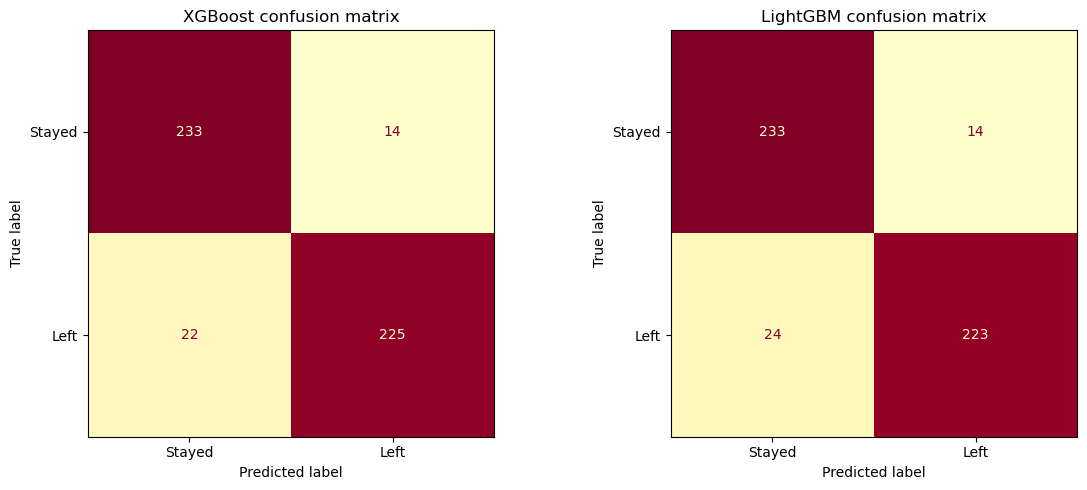

In [6]:
# Cell 5 — Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes,
                             [xgb_preds, lgb_preds],
                             ['XGBoost', 'LightGBM']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='YlOrRd')
    ax.set_title(f'{title} confusion matrix')

plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=150)
plt.show()

In [7]:
# Cell 6 — Cross-validation comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')
lgb_cv = cross_val_score(lgb_model, X, y, cv=cv, scoring='roc_auc')

print(f"XGBoost  CV AUC: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")
print(f"LightGBM CV AUC: {lgb_cv.mean():.4f} ± {lgb_cv.std():.4f}")

XGBoost  CV AUC: 0.9791 ± 0.0051
LightGBM CV AUC: 0.9778 ± 0.0056


In [8]:
# Cell 7 — Optuna tuning for best model (run once, takes ~3 mins)
import optuna

def objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 10),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 10),
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': 42
    }
    model = xgb.XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train,
                            cv=3, scoring='roc_auc').mean()
    return score

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"Best AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best AUC: 0.9762
Best params: {'n_estimators': 260, 'max_depth': 7, 'learning_rate': 0.06553364014471975, 'subsample': 0.8520461856904686, 'colsample_bytree': 0.6496398698053378, 'min_child_weight': 1}


In [9]:
# Cell 8 — Train final tuned model
best_params = study.best_params
best_params.update({'use_label_encoder': False,
                    'eval_metric': 'logloss',
                    'random_state': 42})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)
final_proba = final_model.predict_proba(X_test)[:, 1]
final_preds = final_model.predict(X_test)

print("Tuned XGBoost:")
print(classification_report(y_test, final_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, final_proba):.4f}")

Tuned XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       247
           1       0.94      0.90      0.92       247

    accuracy                           0.92       494
   macro avg       0.92      0.92      0.92       494
weighted avg       0.92      0.92      0.92       494

ROC-AUC: 0.9819
